# IPTC × acessibilidade a empregos — o índice oficial e o que a viagem entrega
### EDA 04 · Projeto Integrador 3º Tri · PADS

**A pergunta deste notebook.** A SPTrans publica o **IPTC — Índice de Permeabilidade do Transporte
Coletivo**, com nota 0–100 por distrito e **72,16** para a cidade em 2025. A rede de ônibus, metrô
e CPTM cobre o município. E ainda assim, na nossa base, **19,5% dos empregos** são alcançáveis em
uma hora de transporte público.

Este notebook **coloca o IPTC na nossa base** e o **cruza** com o indicador que o grupo trata como
alvo de melhoria: a acessibilidade a empregos em ≤60 min. Não montamos um índice novo a partir dos
pesos do IPTC. O argumento é o cruzamento:

| Parte | Entrega |
|:--|:--|
| **1 · IPTC na base** | 96 notas oficiais ligadas aos hexágonos, validadas |
| **2 · O que o IPTC privilegia** | Por que o índice pode parecer bom com acesso ruim |
| **3–5 · O cruzamento** | IPTC × `% do mercado em 60 min` — mapas, escala, classes, ponto cego |
| **6 · Indicador para decisão** | Onde a permeabilidade oficial e o acesso real divergem |

**Fonte do IPTC:** Relatório Integrado da Administração 2025
([capítulo do IPTC](https://www.sptrans.com.br/relatorio-integrado-da-administracao-2025/#ctx-9591)).
Notas em `dados/externo/iptc_2025_distritos.csv`; limites em `dados/externo/distritos-sp.geojson`.

---
## 1 · Preparação

In [1]:
import warnings
from pathlib import Path

import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
from scipy.stats import spearmanr

warnings.filterwarnings("ignore", message=".*tight_layout.*")
warnings.filterwarnings("ignore", message=".*Geometry is in a geographic CRS.*")
warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 140)
pd.set_option("display.max_colwidth", 90)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

S1, S2 = "#2a78d6", "#eb6834"
INK, INK2, INK3 = "#0b0b0b", "#52514e", "#87857c"
SURFACE, GRID = "#fcfcfb", "#e6e5e1"
SEQ = LinearSegmentedColormap.from_list("seq_blue", ["#f2f7fd", "#9dc4ee", "#2a78d6", "#123c6f"])
SEQ2 = LinearSegmentedColormap.from_list("seq_warm", ["#fdf3ec", "#f6c6a3", "#eb6834", "#8c2f08"])

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.linewidth": 1.0,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "text.color": INK, "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2,
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "axes.titlepad": 22,
    "figure.dpi": 110, "lines.linewidth": 2, "lines.markersize": 8,
})

def titulo(ax, t, sub=None):
    ax.set_title(t, color=INK)
    if sub:
        ax.text(0, 1.015, sub, transform=ax.transAxes, fontsize=9, color=INK2, va="bottom")

def limpar_mapa(ax):
    ax.set_aspect(1 / np.cos(np.radians(-23.6)))
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    for s in ax.spines.values():
        s.set_visible(False)

def barra_h(ax, sc, rotulo):
    cb = plt.colorbar(sc, ax=ax, orientation="horizontal", fraction=0.04, pad=0.02, aspect=32)
    cb.set_label(rotulo, fontsize=9, color=INK2)
    cb.outline.set_visible(False)
    cb.ax.tick_params(labelsize=8.5)
    return cb

def pond(v, w):
    v, w = np.asarray(v, float), np.asarray(w, float)
    m = np.isfinite(v) & np.isfinite(w)
    return np.average(v[m], weights=w[m])

def percentil_pond(valores, pesos, q):
    o = np.argsort(np.asarray(valores, float))
    v, w = np.asarray(valores, float)[o], np.asarray(pesos, float)[o]
    c = np.cumsum(w) - 0.5 * w
    return np.interp(q / 100 * w.sum(), c, v)

def sp(a, b):
    return spearmanr(a, b).statistic

print("ambiente ok · pandas", pd.__version__, "· geopandas", gpd.__version__)

ambiente ok · pandas 2.3.3 · geopandas 1.1.4


### Passo 1.1 — Grão de trabalho e o alvo: `% do mercado em 60 min`

Recorte igual aos EDAs anteriores: **hexágono habitado, 2019**, transporte público no pico.
`pct60` é a fração dos empregos formais da cidade alcançáveis em ≤60 minutos — o target de
melhoria para a SPTrans.

In [2]:
def achar(nome="acessibilidade_sp_2017_2019.csv"):
    for raiz in [Path.cwd(), *Path.cwd().parents]:
        for p in (raiz / "dados" / "saida" / nome, raiz / nome):
            if p.exists():
                return p
    raise FileNotFoundError(nome)

CAMINHO = achar()
RAIZ = CAMINHO.parents[2]
df = pd.read_csv(CAMINHO, encoding="utf-8-sig", low_memory=False)

ACC = ["empregos_15min", "empregos_30min", "empregos_60min", "empregos_90min",
       "empregos_120min", "pessoas_que_alcancam_60min"]

def corte(modo, periodo, cols):
    s = df[(df.ano == 2019) & (df.modo == modo) & (df.periodo == periodo)]
    return s.set_index("id_hex")[cols]

fixo = (df[(df.ano == 2019) & (df.modo == "transporte_publico") & (df.periodo == "pico")]
        .set_index("id_hex"))
TOT19 = fixo.empregos_total.sum()

hx = (fixo[["lon", "lat", "pop_total", "renda_per_capita", "decil_renda", "empregos_total"]]
      .join(corte("transporte_publico", "pico",      ACC).add_prefix("tp_"))
      .join(corte("transporte_publico", "fora_pico", ["empregos_60min"]).add_prefix("tpf_"))
      .join(corte("automovel", "pico", ["empregos_60min"]).add_prefix("car_")))
hx = hx[hx.pop_total > 0].reset_index()

hx["pct60"]     = hx.tp_empregos_60min / TOT19 * 100
hx["pct60_car"] = hx.car_empregos_60min / TOT19 * 100
hx["dep_pico"]  = ((hx.tp_empregos_60min - hx.tpf_empregos_60min)
                   / hx.tpf_empregos_60min.replace(0, np.nan) * 100)
hx["penal_car"] = hx.car_empregos_60min / hx.tp_empregos_60min.replace(0, np.nan)

ACESSO_CIDADE = pond(hx.pct60, hx.pop_total)
MEDIANA_ACESSO = percentil_pond(hx.pct60, hx.pop_total, 50)

print(f"base   : {CAMINHO}")
print(f"grão   : {len(hx):,} hexágonos · {hx.pop_total.sum():,.0f} moradores (Censo 2010)")
print(f"mercado: {TOT19:,.0f} empregos formais (2019)")
print(f"acesso médio ponderado (TP, pico) : {ACESSO_CIDADE:.2f}%")
print(f"mediana ponderada da cidade       : {MEDIANA_ACESSO:.1f}%")
print(f"acesso médio de automóvel         : {pond(hx.pct60_car, hx.pop_total):.2f}%")

base   : /Users/danielbauer/Library/CloudStorage/Dropbox/BluStar/Code/PADS/Atividade Integradora 2/dados/saida/acessibilidade_sp_2017_2019.csv
grão   : 9,704 hexágonos · 11,163,678 moradores (Censo 2010)
mercado: 3,461,972 empregos formais (2019)
acesso médio ponderado (TP, pico) : 19.52%
mediana ponderada da cidade       : 13.5%
acesso médio de automóvel         : 75.33%


### Passo 1.2 — Ligar hexágonos aos 96 distritos e às notas do IPTC

In [3]:
DIST = RAIZ / "dados" / "externo" / "distritos-sp.geojson"
IPTC = RAIZ / "dados" / "externo" / "iptc_2025_distritos.csv"

gdf = gpd.read_file(DIST)[["ds_codigo", "ds_nome", "ds_subpref", "geometry"]]
gdf["ds_codigo"] = gdf.ds_codigo.astype(int)
iptc = pd.read_csv(IPTC)
gdf = gdf.merge(iptc, on="ds_codigo", validate="one_to_one")

pts = gpd.GeoDataFrame(hx[["id_hex"]], crs="EPSG:4326",
                       geometry=gpd.points_from_xy(hx.lon, hx.lat))
liga = gpd.sjoin(pts, gdf[["ds_codigo", "geometry"]], how="left",
                 predicate="within")[["id_hex", "ds_codigo"]]

orfaos = liga.loc[liga.ds_codigo.isna(), "id_hex"]
if len(orfaos):
    viz = gpd.sjoin_nearest(pts[pts.id_hex.isin(orfaos)].to_crs(31983),
                            gdf[["ds_codigo", "geometry"]].to_crs(31983), how="left")
    liga = pd.concat([liga[liga.ds_codigo.notna()], viz[["id_hex", "ds_codigo"]]])
liga = liga.drop_duplicates("id_hex")

hx = hx.merge(liga, on="id_hex", how="left").merge(
    gdf[["ds_codigo", "ds_nome", "ds_subpref", "iptc_2025"]], on="ds_codigo", how="left")

print(f"distritos com IPTC : {gdf.iptc_2025.notna().sum()} de {len(gdf)}")
print(f"hexágonos ligados  : {hx.ds_codigo.notna().sum():,} de {len(hx):,}")
print(f"  (borda por vizinho mais próximo): {len(orfaos):,}")

distritos com IPTC : 96 de 96
hexágonos ligados  : 9,704 de 9,704
  (borda por vizinho mais próximo): 147


### Passo 1.3 — A transcrição é auditável

In [4]:
CIDADE_OFICIAL = 72.16
reproduzido = pond(hx.iptc_2025, hx.pop_total)

ANCORAS = [("REPUBLICA", "República, 90%", 89.6), ("BRAS", "Brás, 87%", 86.8),
           ("PARELHEIROS", "Parelheiros, 58%", 57.6), ("MARSILAC", "Marsilac, 42%", 41.5)]
aud = pd.DataFrame([{"âncora no relatório": txt,
                     "nota transcrita": gdf.loc[gdf.ds_nome == nome, "iptc_2025"].iloc[0],
                     "confere": "sim" if abs(gdf.loc[gdf.ds_nome == nome, "iptc_2025"].iloc[0] - v) < .01 else "NÃO"}
                    for nome, txt, v in ANCORAS])
display(aud)

print(f"nota da cidade (SPTrans)                         : {CIDADE_OFICIAL:.2f}")
print(f"média das 96 notas ponderada pela nossa população: {reproduzido:.2f}")
print(f"diferença                                        : {abs(reproduzido - CIDADE_OFICIAL):.2f} ponto")

,âncora no relatório,nota transcrita,confere
0,"República, 90%",89.60,sim
1,"Brás, 87%",86.80,sim
2,"Parelheiros, 58%",57.60,sim
3,"Marsilac, 42%",41.50,sim


nota da cidade (SPTrans)                         : 72.16
média das 96 notas ponderada pela nossa população: 72.11
diferença                                        : 0.05 ponto


> **Achado 1 — a transcrição reproduz o número oficial (erro de 0,05 ponto).**
> As âncoras do texto conferem e a média ponderada dá **72,11** contra **72,16**. O IPTC oficial
> passa a ser coluna auditável na nossa base.

---
## 2 · Por que o IPTC pode parecer bom com acesso ruim

Não usamos os pesos abaixo para construir o nosso indicador. Eles servem só para **explicar a
arquitetura** do índice oficial: quase tudo mede oferta no ponto de parada; o resultado da viagem
(acesso a empregos) pesa **1 em 12**.

In [5]:
pesos = pd.DataFrame([
    ("Ocupação Média dos Veículos BC/PM", 3, "oferta · conforto",  "passageiros em pé por m² no pico manhã"),
    ("Atendimento da Rede Diurna",        2, "oferta · cobertura", "% da população a ≤300 m de um ponto"),
    ("Frequência Média nos Pontos BC/PM", 2, "oferta · serviço",   "ônibus por hora no ponto"),
    ("Atendimento da Rede Noturna",       1, "oferta · cobertura", "% coberto pela rede da madrugada"),
    ("Intervalo Médio das Linhas BC/PM",  1, "oferta · serviço",   "espera média entre veículos da linha"),
    ("Idade Média da Oferta de Viagens",  1, "oferta · frota",     "idade dos veículos, ponderada por viagem"),
    ("Acesso a Empregos",                 1, "RESULTADO",          "% dos empregos alcançáveis"),
    ("Declividade",                       1, "território",         "inclinação média das vias"),
], columns=["indicador", "peso", "natureza", "o que mede"])
pesos["% do índice"] = pesos.peso / pesos.peso.sum() * 100
display(pesos)

print(f"peso da OFERTA (ônibus/frota/cobertura) : {pesos.loc[pesos.natureza.str.startswith('oferta'), 'peso'].sum()} / 12")
print(f"peso do RESULTADO (acesso a empregos)   : 1 / 12  ({100/12:.1f}% do índice)")
print(f"lotação pesa {3}× mais que acesso a emprego")

,indicador,peso,natureza,o que mede,% do índice
0,Ocupação Média dos Veículos BC/PM,3,oferta · conforto,passageiros em pé por m² no pico manhã,25.00
1,Atendimento da Rede Diurna,2,oferta · cobertura,% da população a ≤300 m de um ponto,16.67
2,Frequência Média nos Pontos BC/PM,2,oferta · serviço,ônibus por hora no ponto,16.67
3,Atendimento da Rede Noturna,1,oferta · cobertura,% coberto pela rede da madrugada,8.33
4,Intervalo Médio das Linhas BC/PM,1,oferta · serviço,espera média entre veículos da linha,8.33
5,Idade Média da Oferta de Viagens,1,oferta · frota,"idade dos veículos, ponderada por viagem",8.33
6,Acesso a Empregos,1,RESULTADO,% dos empregos alcançáveis,8.33
7,Declividade,1,território,inclinação média das vias,8.33


peso da OFERTA (ônibus/frota/cobertura) : 10 / 12
peso do RESULTADO (acesso a empregos)   : 1 / 12  (8.3% do índice)
lotação pesa 3× mais que acesso a emprego


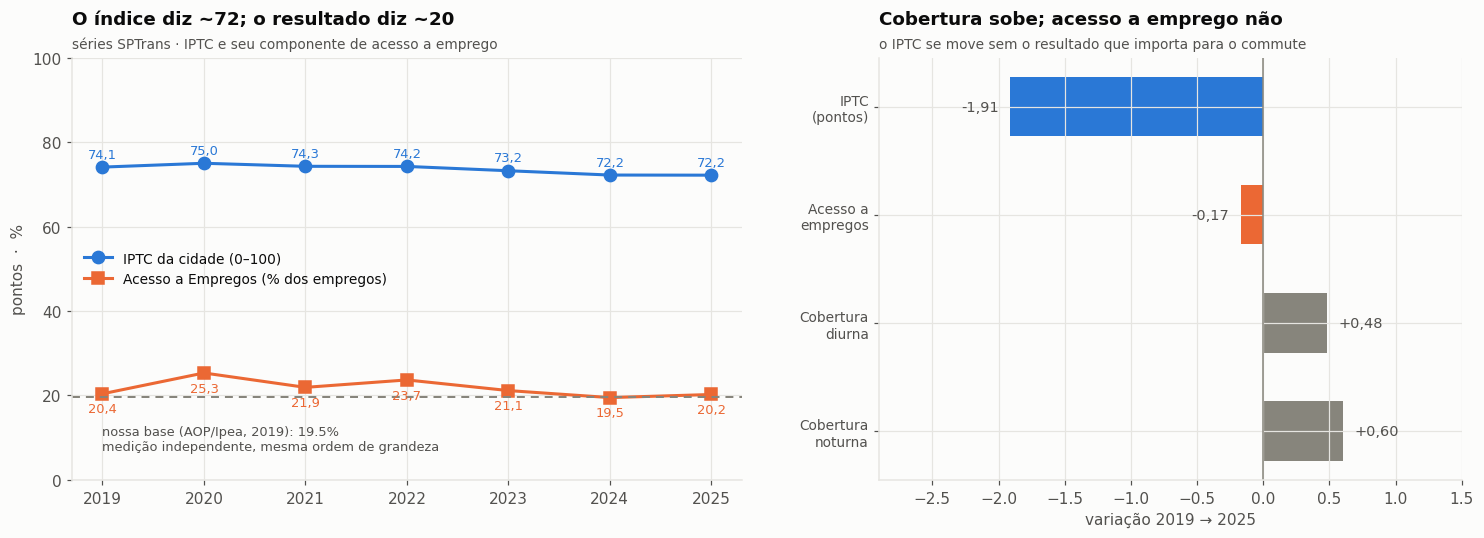

acesso a empregos SPTrans 2019 → 2025: 20.39% → 20.22%  (-0.17 p.p.)
nossa base AOP/Ipea, 2019            : 19.52%  (diferença de 0.87 p.p.)


In [6]:
# séries do Relatório Integrado 2025 — o próprio componente "Acesso a Empregos" da SPTrans
serie = pd.DataFrame({
    "ano":               [2019, 2020, 2021, 2022, 2023, 2024, 2025],
    "iptc":              [74.07, 74.98, 74.26, 74.23, 73.21, 72.19, 72.16],
    "acesso_empregos":   [20.39, 25.32, 21.91, 23.67, 21.15, 19.49, 20.22],
    "cobertura_diurna":  [95.42, 95.40, 95.55, 95.62, 95.70, 95.86, 95.90],
    "cobertura_noturna": [64.74, 64.87, 64.85, 64.91, 65.07, 65.29, 65.34],
})

fig, axes = plt.subplots(1, 2, figsize=(13.6, 5.0), width_ratios=[1.15, 1])

ax = axes[0]
ax.plot(serie.ano, serie.iptc, color=S1, marker="o", label="IPTC da cidade (0–100)")
ax.plot(serie.ano, serie.acesso_empregos, color=S2, marker="s",
        label="Acesso a Empregos (% dos empregos)")
ax.axhline(ACESSO_CIDADE, color=INK3, lw=1.3, ls=(0, (4, 3)))
ax.text(2019, ACESSO_CIDADE - 12.5,
        f"nossa base (AOP/Ipea, 2019): {ACESSO_CIDADE:.1f}%\n"
        f"medição independente, mesma ordem de grandeza",
        fontsize=8.5, color=INK2)
for a, v in zip(serie.ano, serie.iptc):
    ax.text(a, v + 2.2, f"{v:.1f}".replace(".", ","), fontsize=8.5, color=S1, ha="center")
for a, v in zip(serie.ano, serie.acesso_empregos):
    ax.text(a, v - 4.4, f"{v:.1f}".replace(".", ","), fontsize=8.5, color=S2, ha="center")
ax.set_ylim(0, 100); ax.set_ylabel("pontos  ·  %")
ax.legend(frameon=False, fontsize=9, loc="center left")
titulo(ax, "O índice diz ~72; o resultado diz ~20",
       "séries SPTrans · IPTC e seu componente de acesso a emprego")

ax = axes[1]
b = (serie.set_index("ano")[["iptc", "acesso_empregos", "cobertura_diurna", "cobertura_noturna"]]
     .pipe(lambda d: d.loc[2025] - d.loc[2019]))
rot = ["IPTC\n(pontos)", "Acesso a\nempregos", "Cobertura\ndiurna", "Cobertura\nnoturna"]
cor = [S1, S2, INK3, INK3]
y = np.arange(len(b))[::-1]
ax.barh(y, b.values, color=cor, height=0.55)
for yi, v in zip(y, b.values):
    ax.text(v + (0.09 if v >= 0 else -0.09), yi, f"{v:+.2f}".replace(".", ","),
            va="center", ha="left" if v >= 0 else "right", fontsize=9.5, color=INK2)
ax.set_yticks(y, rot, fontsize=9)
ax.axvline(0, color=INK3, lw=1)
ax.set_xlim(-2.9, 1.5)
ax.set_xlabel("variação 2019 → 2025")
titulo(ax, "Cobertura sobe; acesso a emprego não",
       "o IPTC se move sem o resultado que importa para o commute")
plt.tight_layout(); plt.subplots_adjust(wspace=0.22); plt.show()

print(f"acesso a empregos SPTrans 2019 → 2025: {serie.acesso_empregos.iloc[0]:.2f}% → "
      f"{serie.acesso_empregos.iloc[-1]:.2f}%  ({serie.acesso_empregos.iloc[-1] - serie.acesso_empregos.iloc[0]:+.2f} p.p.)")
print(f"nossa base AOP/Ipea, 2019            : {ACESSO_CIDADE:.2f}%  "
      f"(diferença de {abs(serie.acesso_empregos.iloc[0] - ACESSO_CIDADE):.2f} p.p.)")

> **Achado 2 — a SPTrans e a nossa base medem o mesmo resultado; o que muda é o peso dado a ele.**
> O componente "Acesso a Empregos" do IPTC era **20,39%** em 2019; nossa base dá **19,52%**. Em seis
> anos o resultado quase não saiu do lugar (−0,17 p.p.), enquanto cobertura diurna/noturna subiu e
> o IPTC caiu por outros motivos. A comparação IPTC 2025 × acessibilidade 2019 é defensável porque
> **o resultado ficou estável** na série da própria operadora.

---
## 3 · O cruzamento: IPTC × `% do mercado em 60 min`

À esquerda, a classificação oficial. À direita, o que a viagem entrega no mesmo território.

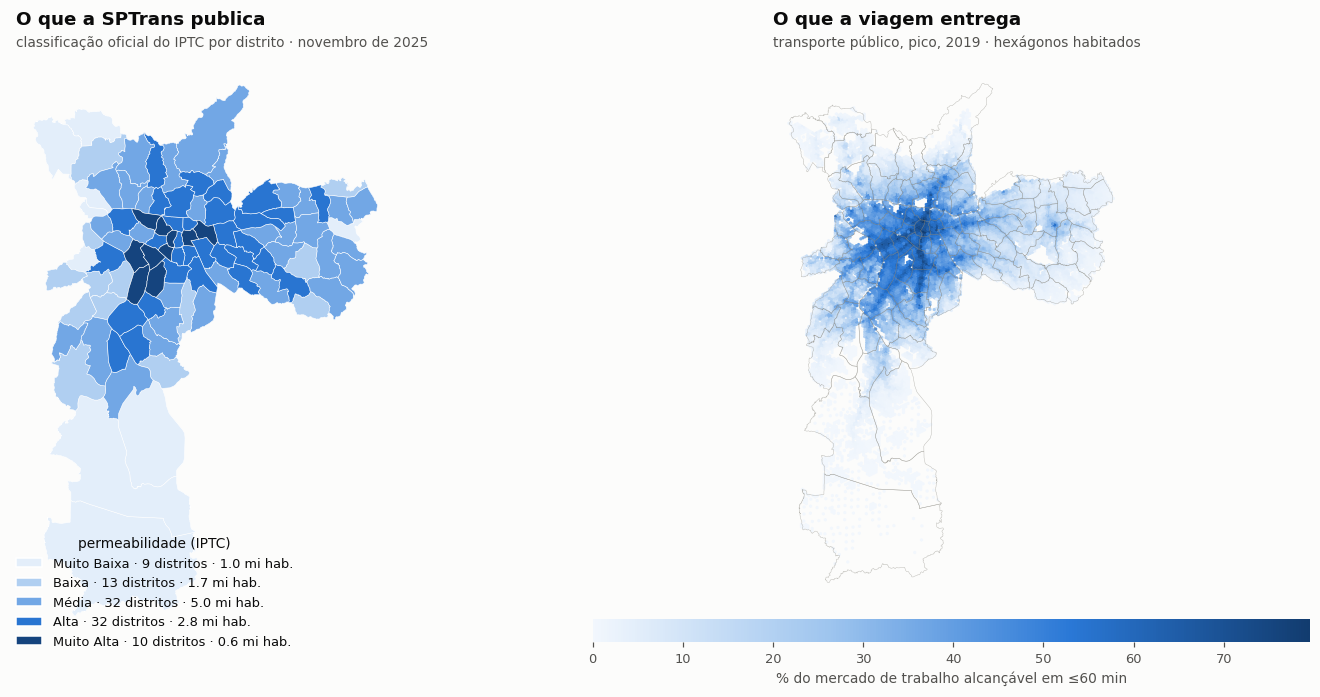

In [7]:
CLASSES = [(63.6, "Muito Baixa"), (69.3, "Baixa"), (73.4, "Média"), (82.0, "Alta"), (101, "Muito Alta")]
ORDEM_CLASSE = ["Muito Baixa", "Baixa", "Média", "Alta", "Muito Alta"]

def classificar(v):
    for lim, nome in CLASSES:
        if v <= lim:
            return nome
    return "Muito Alta"

hx["classe_iptc"] = hx.iptc_2025.map(classificar)
gdf["classe_iptc"] = gdf.iptc_2025.map(classificar)

D = (hx.groupby("ds_codigo")
       .apply(lambda x: pd.Series({
           "pop":       x.pop_total.sum(),
           "pct60":     pond(x.pct60, x.pop_total),
           "pct60_car": pond(x.pct60_car, x.pop_total),
           "dep_pico":  pond(x.dep_pico.fillna(0), x.pop_total),
           "penal_car": percentil_pond(x.penal_car.fillna(x.penal_car.max()), x.pop_total, 50),
           "renda":     pond(x.renda_per_capita.fillna(0), x.pop_total),
           "hexagonos": len(x),
       }), include_groups=False)
       .reset_index()
       .merge(gdf.drop(columns="geometry"), on="ds_codigo"))
Dg = gdf.merge(D.drop(columns=["ds_nome", "ds_subpref", "iptc_2025", "classe_iptc"]), on="ds_codigo")

CORES_CLASSE = dict(zip(ORDEM_CLASSE, [SEQ(v) for v in [0.06, 0.26, 0.46, 0.68, 0.95]]))

fig, axes = plt.subplots(1, 2, figsize=(13.6, 6.4))

ax = axes[0]
handles = []
for c, cor in CORES_CLASSE.items():
    s = Dg[Dg.classe_iptc == c]
    s.plot(color=cor, ax=ax, edgecolor="white", linewidth=0.35)
    pop_c = hx.loc[hx.classe_iptc == c, "pop_total"].sum() / 1e6
    handles.append(Patch(facecolor=cor, edgecolor="white",
                         label=f"{c} · {len(s)} distritos · {pop_c:.1f} mi hab."))
limpar_mapa(ax)
ax.legend(handles=handles, frameon=False, fontsize=8.5, loc="lower left",
          bbox_to_anchor=(-0.03, -0.03), title="permeabilidade (IPTC)", title_fontsize=9)
titulo(ax, "O que a SPTrans publica",
       "classificação oficial do IPTC por distrito · novembro de 2025")

ax = axes[1]
sc = ax.scatter(hx.lon, hx.lat, c=hx.pct60, s=5.5, marker="h", cmap=SEQ,
                linewidths=0, rasterized=True)
Dg.boundary.plot(ax=ax, color=INK3, linewidth=0.3, alpha=0.55)
limpar_mapa(ax)
barra_h(ax, sc, "% do mercado de trabalho alcançável em ≤60 min")
titulo(ax, "O que a viagem entrega", "transporte público, pico, 2019 · hexágonos habitados")
plt.tight_layout(); plt.subplots_adjust(wspace=0.04); plt.show()

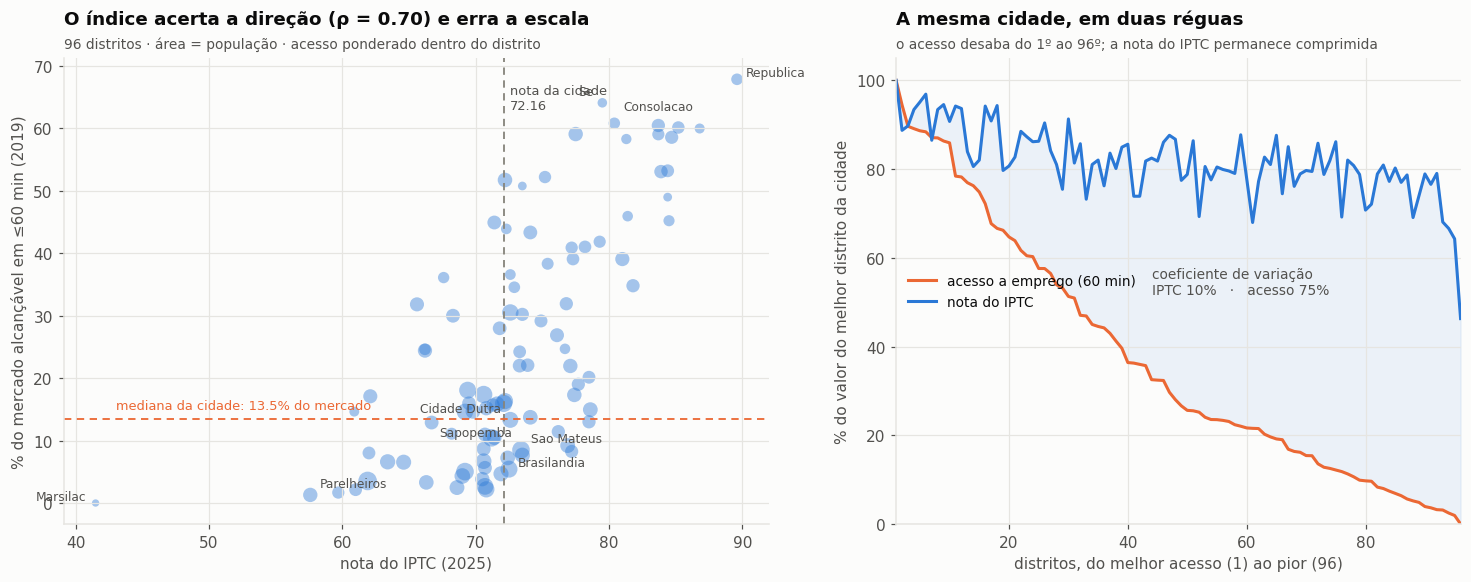

IPTC   : p10 =  65.1  p90 =  82.8   → razão p90/p10 =  1.27×
acesso : p10 =   4.1% p90 =  55.7%  → razão p90/p10 =  13.6×
coeficiente de variação: IPTC 9.9%  vs  acesso 75.0%  →  compressão de 7.6×


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13.6, 5.4), width_ratios=[1.25, 1])

ax = axes[0]
ax.scatter(D.iptc_2025, D.pct60, s=np.sqrt(D["pop"]) / 4, color=S1, alpha=0.42, linewidths=0)
rotular = pd.concat([D.nlargest(3, "pct60"), D.nsmallest(2, "pct60"),
                     D[(D.iptc_2025 > CIDADE_OFICIAL) & (D.pct60 < MEDIANA_ACESSO)].nlargest(4, "pop")])
for k, (_, r) in enumerate(rotular.drop_duplicates("ds_codigo").iterrows()):
    dx, ha = ((6, "left") if k % 2 == 0 else (-6, "right"))
    ax.annotate(r.ds_nome.title(), (r.iptc_2025, r.pct60), fontsize=8, color=INK2,
                xytext=(dx, 2.0 + 3.4 * (k % 3)), textcoords="offset points", ha=ha)
ax.axvline(CIDADE_OFICIAL, color=INK3, lw=1.2, ls=(0, (4, 3)))
ax.text(CIDADE_OFICIAL + 0.4, 63, f"nota da cidade\n{CIDADE_OFICIAL}", fontsize=8.5, color=INK2)
ax.axhline(MEDIANA_ACESSO, color=S2, lw=1.2, ls=(0, (4, 3)))
ax.text(43, MEDIANA_ACESSO + 1.5, f"mediana da cidade: {MEDIANA_ACESSO:.1f}% do mercado",
        fontsize=8.5, color=S2)
ax.set_xlabel("nota do IPTC (2025)")
ax.set_ylabel("% do mercado alcançável em ≤60 min (2019)")
titulo(ax, f"O índice acerta a direção (ρ = {sp(D.iptc_2025, D.pct60):.2f}) e erra a escala",
       "96 distritos · área = população · acesso ponderado dentro do distrito")

ax = axes[1]
o = D.sort_values("pct60", ascending=False).reset_index(drop=True)
xx = np.arange(1, len(o) + 1)
ax.plot(xx, o.pct60 / o.pct60.max() * 100, color=S2, label="acesso a emprego (60 min)")
ax.plot(xx, o.iptc_2025 / o.iptc_2025.max() * 100, color=S1, label="nota do IPTC")
ax.fill_between(xx, o.pct60 / o.pct60.max() * 100, o.iptc_2025 / o.iptc_2025.max() * 100,
                color=S1, alpha=0.08)
ax.set_ylim(0, 105); ax.set_xlim(1, 96)
ax.set_xlabel("distritos, do melhor acesso (1) ao pior (96)")
ax.set_ylabel("% do valor do melhor distrito da cidade")
ax.legend(frameon=False, fontsize=9, loc="center left")
cvI = D.iptc_2025.std() / D.iptc_2025.mean() * 100
cvA = D.pct60.std() / D.pct60.mean() * 100
ax.text(44, 58, f"coeficiente de variação\nIPTC {cvI:.0f}%   ·   acesso {cvA:.0f}%",
        fontsize=9, color=INK2, va="top")
titulo(ax, "A mesma cidade, em duas réguas",
       "o acesso desaba do 1º ao 96º; a nota do IPTC permanece comprimida")
plt.tight_layout(); plt.subplots_adjust(wspace=0.2); plt.show()

razao = lambda s: s.quantile(.9) / s.quantile(.1)
print(f"IPTC   : p10 = {D.iptc_2025.quantile(.1):5.1f}  p90 = {D.iptc_2025.quantile(.9):5.1f}   → razão p90/p10 = {razao(D.iptc_2025):5.2f}×")
print(f"acesso : p10 = {D.pct60.quantile(.1):5.1f}% p90 = {D.pct60.quantile(.9):5.1f}%  → razão p90/p10 = {razao(D.pct60):5.1f}×")
print(f"coeficiente de variação: IPTC {cvI:.1f}%  vs  acesso {cvA:.1f}%  →  compressão de {cvA/cvI:.1f}×")

> **Achado 3 — o IPTC ordena (ρ ≈ 0,70) e comprime a desigualdade.**
> Entre o percentil 10 e o 90 dos distritos, o acesso a emprego varia **~13×** e o IPTC **~1,3×**.
> Pares que mostram a falha de escala: **Saúde** (IPTC 72,2 · **51,7%** do mercado) e
> **Brasilândia** (IPTC **72,5** · **5,5%**); **Vila Sônia** (68,3 · 30%) e **São Rafael**
> (68,6 · 2,5%). Nota quase igual, acesso de outra ordem de grandeza.

---
## 4 · Classificação oficial × acesso real

In [9]:
tab = (hx.groupby("classe_iptc")
         .apply(lambda x: pd.Series({
             "distritos":        x.ds_codigo.nunique(),
             "população (mi)":   x.pop_total.sum() / 1e6,
             "% da cidade":      x.pop_total.sum() / hx.pop_total.sum() * 100,
             "acesso médio (%)": pond(x.pct60, x.pop_total),
             "carro entrega ×":  percentil_pond(
                 x.penal_car.fillna(x.penal_car.max()), x.pop_total, 50),
         }), include_groups=False)
         .reindex(ORDEM_CLASSE))
display(tab.round(1))

boa = tab.loc[["Média", "Alta", "Muito Alta"]]
print(f"distritos 'Média' ou melhor: {boa.distritos.sum():.0f} de 96")
print(f"população nesses distritos : {boa['população (mi)'].sum():.2f} mi "
      f"({boa['% da cidade'].sum():.0f}% da cidade)")

sub = hx[hx.classe_iptc.isin(["Média", "Alta", "Muito Alta"])]
print(f"dentro deles, pop. com acesso <10% do mercado em 1h: "
      f"{sub[sub.pct60 < 10].pop_total.sum()/1e6:.2f} mi")

,distritos,população (mi),% da cidade,acesso médio (%),carro entrega ×
classe_iptc,,,,,
Muito Baixa,9.00,1.00,9.10,5.70,10.10
Baixa,13.00,1.70,15.40,12.90,8.50
Média,32.00,5.00,44.50,15.00,6.20
Alta,32.00,2.80,25.20,28.00,3.80
Muito Alta,10.00,0.60,5.70,57.20,1.70


distritos 'Média' ou melhor: 74 de 96
população nesses distritos : 8.42 mi (75% da cidade)
dentro deles, pop. com acesso <10% do mercado em 1h: 2.75 mi


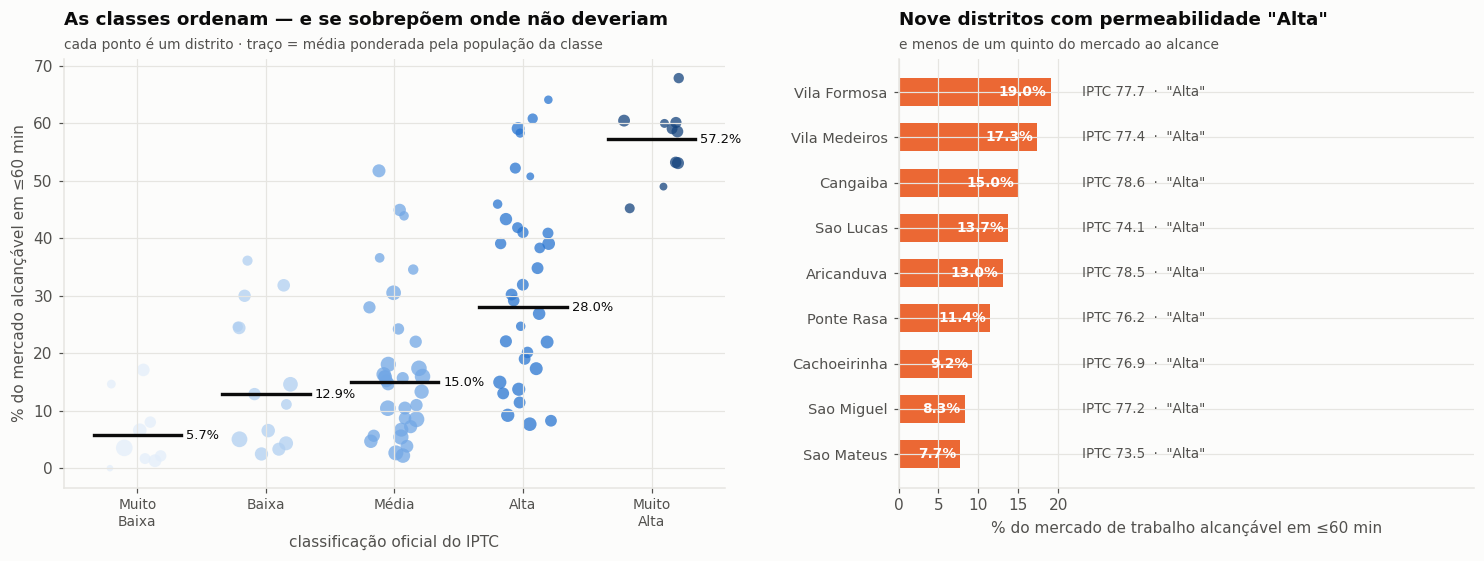

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13.6, 5.2), width_ratios=[1.15, 1])
rng = np.random.default_rng(0)

ax = axes[0]
for i, c in enumerate(ORDEM_CLASSE):
    s = D[D.classe_iptc == c]
    ax.scatter(np.full(len(s), i) + rng.uniform(-0.22, 0.22, len(s)), s.pct60,
               s=np.sqrt(s["pop"]) / 5, color=CORES_CLASSE[c], alpha=0.75, linewidths=0)
    if len(s):
        m = pond(hx.loc[hx.classe_iptc == c, "pct60"], hx.loc[hx.classe_iptc == c, "pop_total"])
        ax.plot([i - 0.34, i + 0.34], [m, m], color=INK, lw=2.2, zorder=5)
        ax.text(i + 0.38, m, f"{m:.1f}%", fontsize=8.5, color=INK, va="center")
ax.set_xticks(range(5), [c.replace(" ", "\n") for c in ORDEM_CLASSE], fontsize=9)
ax.set_ylabel("% do mercado alcançável em ≤60 min")
ax.set_xlabel("classificação oficial do IPTC")
titulo(ax, "As classes ordenam — e se sobrepõem onde não deveriam",
       "cada ponto é um distrito · traço = média ponderada pela população da classe")

ax = axes[1]
piores = D[D.classe_iptc.isin(["Alta", "Muito Alta"])].nsmallest(9, "pct60").sort_values("pct60")
y = np.arange(len(piores))
ax.barh(y, piores.pct60, color=S2, height=0.62)
for yi, r in zip(y, piores.itertuples()):
    ax.text(r.pct60 - 0.5, yi, f"{r.pct60:.1f}%", fontsize=9, color="white", va="center",
            ha="right", fontweight="bold")
    ax.text(23.0, yi, f"IPTC {r.iptc_2025:.1f}  ·  \"{r.classe_iptc}\"",
            fontsize=8.8, color=INK2, va="center")
ax.set_yticks(y, [n.title() for n in piores.ds_nome], fontsize=9.5)
ax.set_xlim(0, 72); ax.set_xticks([0, 5, 10, 15, 20])
ax.set_xlabel("% do mercado de trabalho alcançável em ≤60 min")
titulo(ax, "Nove distritos com permeabilidade \"Alta\"",
       "e menos de um quinto do mercado ao alcance")
plt.tight_layout(); plt.subplots_adjust(wspace=0.28); plt.show()

> **Achado 4 — 75% da cidade está em distrito "Média ou melhor"; 2,75 mi dessas pessoas não
> alcançam 10% do mercado em uma hora.**
> A classe "Alta" inclui São Mateus (7,7%) e São Miguel (8,3%). O IPTC avalia o ônibus contra o
> próprio ônibus; o commute compara com o carro — na "Muito Baixa" o carro entrega ~10× mais
> mercado; na "Muito Alta", ~1,7×.

---
## 5 · O ponto cego: IPTC acima da média, acesso abaixo da mediana

O indicador de decisão deste notebook **é o cruzamento**, não um índice composto. Eixo
horizontal = nota oficial. Eixo vertical = `% do mercado em 60 min`. O quadrante de interesse:
permeabilidade **acima da nota da cidade** e acesso **abaixo da mediana ponderada**.

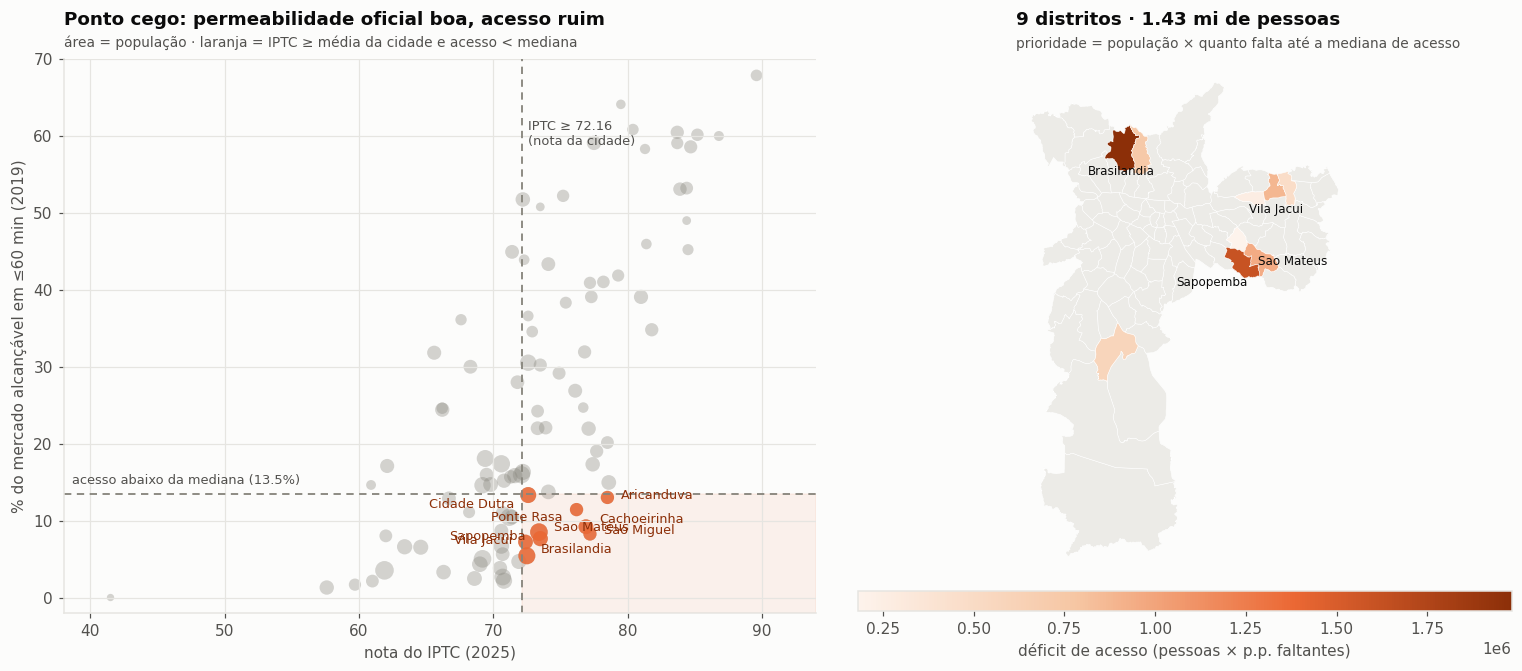

,distrito,subprefeitura,IPTC,classe oficial,% do mercado (60 min),carro entrega ×,população,déficit (pessoas × p.p.)
1,BRASILANDIA,FREGUESIA-BRASILANDIA,72.50,Média,5.50,18.10,"244,763.00","1,983,039.10"
2,SAPOPEMBA,SAPOPEMBA,73.40,Média,8.50,8.50,"282,269.00","1,609,127.40"
3,SAO MATEUS,SAO MATEUS,73.50,Alta,7.70,8.50,"157,007.00","953,357.60"
4,VILA JACUI,SAO MIGUEL,72.40,Média,7.20,7.80,"137,754.00","881,179.80"
5,CACHOEIRINHA,CASA VERDE-CACHOEIRINHA,76.90,Alta,9.20,10.50,"143,332.00","740,846.10"
6,CIDADE DUTRA,CAPELA DO SOCORRO,72.60,Média,13.30,5.20,"192,289.00","588,310.90"
7,SAO MIGUEL,SAO MIGUEL,77.20,Alta,8.30,5.40,"88,434.00","478,817.70"
8,PONTE RASA,ERMELINO MATARAZZO,76.20,Alta,11.40,7.00,"91,560.00","260,083.80"
9,ARICANDUVA,ARICANDUVA-FORMOSA-CARRAO,78.50,Alta,13.00,7.10,"91,248.00","180,098.60"


população no ponto cego: 1.43 mi (13% da cidade)
déficit nesses distritos: 7.7 mi de pessoa×p.p. (18% do déficit total da cidade)


In [11]:
# déficit de acesso: pessoas × pontos percentuais faltantes até a mediana (prioridade simples)
hx["deficit"] = (hx.pop_total * (MEDIANA_ACESSO - hx.pct60)).clip(lower=0)
D["deficit"] = hx.groupby("ds_codigo").deficit.sum().reindex(D.ds_codigo).values

cego = (D[(D.iptc_2025 >= CIDADE_OFICIAL) & (D.pct60 < MEDIANA_ACESSO)]
          .sort_values("deficit", ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(14.2, 6.2), width_ratios=[1.15, 1])

ax = axes[0]
ax.axhspan(-2, MEDIANA_ACESSO, xmin=(CIDADE_OFICIAL - 38) / (94 - 38),
           color=S2, alpha=0.08, zorder=0)
ax.scatter(D.iptc_2025, D.pct60, s=np.sqrt(D["pop"]) / 4, color=INK3, alpha=0.35, linewidths=0)
ax.scatter(cego.iptc_2025, cego.pct60, s=np.sqrt(cego["pop"]) / 4, color=S2, alpha=0.85, linewidths=0)
OFFSETS = {"BRASILANDIA": (9, 4), "SAO MATEUS": (9, 7), "VILA JACUI": (-9, 1),
           "SAPOPEMBA": (-9, -3), "SAO MIGUEL": (9, 2), "CACHOEIRINHA": (9, 5),
           "PONTE RASA": (-9, -5), "ARICANDUVA": (9, 1), "CANGAIBA": (9, -7),
           "CIDADE DUTRA": (-9, -6), "SAO LUCAS": (9, -4)}
for _, r in cego.iterrows():
    dx, dy = OFFSETS.get(r.ds_nome, (9, 3))
    ax.annotate(r.ds_nome.title(), (r.iptc_2025, r.pct60), fontsize=8.4, color="#8c2f08",
                xytext=(dx, dy), textcoords="offset points",
                ha="left" if dx > 0 else "right", va="center")
ax.axvline(CIDADE_OFICIAL, color=INK3, lw=1.2, ls=(0, (4, 3)))
ax.axhline(MEDIANA_ACESSO, color=INK3, lw=1.2, ls=(0, (4, 3)))
ax.text(CIDADE_OFICIAL + 0.4, 62, f"IPTC ≥ {CIDADE_OFICIAL}\n(nota da cidade)",
        fontsize=8.5, color=INK2, va="top")
ax.text(38.6, MEDIANA_ACESSO + 1.2, f"acesso abaixo da mediana ({MEDIANA_ACESSO:.1f}%)",
        fontsize=8.5, color=INK2)
ax.set_xlim(38, 94); ax.set_ylim(-2, 70)
ax.set_xlabel("nota do IPTC (2025)")
ax.set_ylabel("% do mercado alcançável em ≤60 min (2019)")
titulo(ax, "Ponto cego: permeabilidade oficial boa, acesso ruim",
       "área = população · laranja = IPTC ≥ média da cidade e acesso < mediana")

ax = axes[1]
Dg = gdf.merge(D.drop(columns=["ds_nome", "ds_subpref", "iptc_2025", "classe_iptc"]), on="ds_codigo")
Dg["cego"] = Dg.ds_codigo.isin(cego.ds_codigo)
Dg.plot(color="#ecebe7", ax=ax, edgecolor="white", linewidth=0.35)
Dg[Dg.cego].plot(column="deficit", cmap=SEQ2, ax=ax, edgecolor="white", linewidth=0.35,
                 legend=True, legend_kwds={"orientation": "horizontal", "fraction": 0.04,
                                           "pad": 0.02, "aspect": 32,
                                           "label": "déficit de acesso (pessoas × p.p. faltantes)"})
ROT_MAPA = {"BRASILANDIA": (0, -15), "SAPOPEMBA": (-20, -13), "SAO MATEUS": (19, -2),
            "VILA JACUI": (0, -15)}
for _, r in Dg[Dg.cego].nlargest(4, "deficit").iterrows():
    c = r.geometry.representative_point()
    ax.annotate(r.ds_nome.title(), (c.x, c.y), fontsize=7.8, color=INK, ha="center",
                va="center", xytext=ROT_MAPA.get(r.ds_nome, (0, -15)), textcoords="offset points")
limpar_mapa(ax)
titulo(ax, f"{len(cego)} distritos · {cego['pop'].sum()/1e6:.2f} mi de pessoas",
       "prioridade = população × quanto falta até a mediana de acesso")
plt.tight_layout(); plt.subplots_adjust(wspace=0.06); plt.show()

fila = (cego[["ds_nome", "ds_subpref", "iptc_2025", "classe_iptc", "pct60", "penal_car", "pop", "deficit"]]
        .rename(columns={"ds_nome": "distrito", "ds_subpref": "subprefeitura",
                         "iptc_2025": "IPTC", "classe_iptc": "classe oficial",
                         "pct60": "% do mercado (60 min)", "penal_car": "carro entrega ×",
                         "pop": "população", "deficit": "déficit (pessoas × p.p.)"})
        .reset_index(drop=True))
fila.index += 1
display(fila.round(1))

print(f"população no ponto cego: {cego['pop'].sum()/1e6:.2f} mi "
      f"({cego['pop'].sum()/hx.pop_total.sum()*100:.0f}% da cidade)")
print(f"déficit nesses distritos: {cego.deficit.sum()/1e6:.1f} mi de pessoa×p.p. "
      f"({cego.deficit.sum()/hx.deficit.sum()*100:.0f}% do déficit total da cidade)")

> **Achado 5 — há um conjunto claro de distritos onde o IPTC não alerta e o acesso falha.**
> O cruzamento IPTC ≥ 72,16 e acesso < mediana da cidade isola o ponto cego. O **déficit**
> (`população × pontos percentuais faltantes até a mediana`) ordena esses lugares para
> decisão — sem inventar uma pontuação 0–100 a partir dos pesos do IPTC. Brasilândia, Sapopemba,
> São Mateus e vizinhos da Leste/Norte aparecem com permeabilidade "Média/Alta" e acesso de um
> dígito.

---
## 6 · Indicador para a SPTrans: o que entregar

O entregável não é um IPTC alternativo. É:

1. **O IPTC oficial** (já publicado) — oferta / permeabilidade.
2. **O acesso a empregos em 60 min** (nossa base / componente que a própria SPTrans já mede) —
   resultado do commute.
3. **O cruzamento** — lista de prioridade onde (2) está ruim e (1) não sinaliza.

Isso fala a língua da tomada de decisão: *onde a malha parece adequada no índice e ainda assim o
trabalhador não alcança o mercado de trabalho.*

In [12]:
# resumo executivo numérico
sintese = pd.DataFrame([
    ("IPTC cidade (oficial)", f"{CIDADE_OFICIAL:.2f}"),
    ("IPTC cidade (reproduzido na nossa base)", f"{reproduzido:.2f}"),
    ("Acesso médio a empregos em 60 min (nossa base)", f"{ACESSO_CIDADE:.1f}%"),
    ("Acesso a empregos SPTrans 2019 / 2025",
     f"{serie.acesso_empregos.iloc[0]:.2f}% / {serie.acesso_empregos.iloc[-1]:.2f}%"),
    ("ρ Spearman IPTC × acesso (distritos)", f"{sp(D.iptc_2025, D.pct60):.2f}"),
    ("Razão p90/p10 — IPTC / acesso",
     f"{D.iptc_2025.quantile(.9)/D.iptc_2025.quantile(.1):.2f}× / "
     f"{D.pct60.quantile(.9)/D.pct60.quantile(.1):.1f}×"),
    ("Distritos no ponto cego (IPTC≥cidade e acesso<mediana)", f"{len(cego)}"),
    ("População no ponto cego", f"{cego['pop'].sum()/1e6:.2f} mi"),
], columns=["métrica", "valor"])
display(sintese)

,métrica,valor
0,IPTC cidade (oficial),72.16
1,IPTC cidade (reproduzido na nossa base),72.11
2,Acesso médio a empregos em 60 min (nossa base),19.5%
3,Acesso a empregos SPTrans 2019 / 2025,20.39% / 20.22%
4,ρ Spearman IPTC × acesso (distritos),0.70
5,Razão p90/p10 — IPTC / acesso,1.27× / 13.6×
6,Distritos no ponto cego (IPTC≥cidade e acesso<mediana),9
7,População no ponto cego,1.43 mi


---
## 7 · Síntese

**1.** O IPTC está na base (96 notas × hexágonos), validado contra 72,16.

**2.** O resultado que importa — acesso a empregos — pesa 8,3% no IPTC e ficou ~20% de 2019 a
2025; nossa base confirma 19,5% em 2019.

**3.** Cruzar IPTC × `% do mercado em 60 min` mostra ordenação parcial e **compressão de escala**:
o índice não espelha a desigualdade do commute.

**4.** A classificação oficial acomoda milhões de pessoas com acesso fraco em rótulos "Média/Alta".

**5.** O indicador de decisão é o **ponto cego** (IPTC bom, acesso ruim) ordenado por **déficit de
acesso** — população × quanto falta até a mediana. Sem índice composto a partir dos pesos do IPTC.

### Limitações (para o deck)

| Limitação | Tratamento |
|:--|:--|
| Acessibilidade 2019 × IPTC 2025 | Série SPTrans de acesso a emprego estável (~20%) |
| Censo 2010 como peso | Declarado; efeito tende a subestimar periferia |
| Distrito é grão grosso | Agregação sempre ponderada; análise vive no hexágono |
| Notas do IPTC vieram do mapa | Validadas (âncoras + nota da cidade) |

In [13]:
SAIDA = RAIZ / "dados" / "saida"

COLS_HEX = ["id_hex", "lon", "lat", "ds_codigo", "ds_nome", "ds_subpref",
            "iptc_2025", "classe_iptc", "pop_total", "renda_per_capita", "decil_renda",
            "pct60", "pct60_car", "penal_car", "dep_pico", "deficit"]
hx[COLS_HEX].to_csv(SAIDA / "iptc_custo_commute_hex.csv", index=False)

COLS_D = ["ds_codigo", "ds_nome", "ds_subpref", "iptc_2025", "classe_iptc",
          "pop", "hexagonos", "pct60", "pct60_car", "penal_car", "dep_pico", "renda", "deficit"]
D["ponto_cego"] = D.ds_codigo.isin(cego.ds_codigo)
(D[COLS_D + ["ponto_cego"]].sort_values("deficit", ascending=False)
   .to_csv(SAIDA / "iptc_custo_commute_distritos.csv", index=False))

print("gravado:")
for f in ["iptc_custo_commute_hex.csv", "iptc_custo_commute_distritos.csv"]:
    p = SAIDA / f
    print(f"  {p.relative_to(RAIZ)}  ·  {p.stat().st_size/1024:,.0f} KB")

gravado:
  dados/saida/iptc_custo_commute_hex.csv  ·  1,811 KB
  dados/saida/iptc_custo_commute_distritos.csv  ·  16 KB
